In [1]:
from typing import Any, Optional

import requests
from bs4 import BeautifulSoup

import torch
from transformers import pipeline
from transformers.cache_utils import DynamicCache
import pkgutil
import inspect
import importlib
import re
from kvpress import BasePress, RandomPress

In [2]:
# Dirty hack to add query_states to cache_kwargs in all attention classes
for name in ["qwen2", "llama", "mistral", "phi3"]:
    try:
        submodule = importlib.import_module(f"transformers.models.{name}.modeling_{name}")
        attention_classes = getattr(submodule, f"{name.upper()}_ATTENTION_CLASSES")
        for key, cls in attention_classes.items():
            source_code = inspect.getsource(cls)
            if ("cache_kwargs = " in source_code) and ("query_states = " in source_code): 
                updated_source_code = re.sub(r'cache_kwargs = {(.*?)\}', r'cache_kwargs = {\1, "query_states": query_states}', source_code)
                exec(updated_source_code, submodule.__dict__)
            attention_classes[key] = submodule.__dict__[cls.__name__]
    except (AttributeError, ModuleNotFoundError):
        pass

In [3]:
# Load model and data

device = "cuda:0"
ckpt = "meta-llama/Llama-3.2-3B-Instruct"
attn_implementation = "flash_attention_2"
pipe = pipeline("kv-press-text-generation", model=ckpt, device=device, torch_dtype="auto", model_kwargs={"attn_implementation":attn_implementation})

url = "https://en.wikipedia.org/wiki/Nvidia"
content = requests.get(url).content
soup = BeautifulSoup(content, "html.parser")
context = "".join([p.text for p in soup.find_all("p")]) + "\n\n"

You are attempting to use Flash Attention 2.0 with a model not initialized on GPU. Make sure to move the model to GPU after initializing it on CPU with `model.to('cuda')`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0


In [4]:
from transformers.models.llama.modeling_llama import repeat_kv 

In [40]:
queries = []

In [56]:
LARGE_NEGATIVE_FLOAT = -float(1e5)

class DynamicHeadCache(DynamicCache):
    """
    To use DynamicHeadCache, query_states must be added to cache_kwargs
    This cache will update the keys and values at the specified indices to fake keys and 0 values
    so that for any query, the attention weights at the specified indices will be 0
    """

    def update(
        self,
        key_states: torch.Tensor,
        value_states: torch.Tensor,
        layer_idx: int,
        cache_kwargs: Optional[dict[str, Any]] = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        if self.indices[layer_idx] is not None:
            # Load query states q from cache_kwargs
            q = cache_kwargs["query_states"]
            q_clone = q.clone()
            global queries
            queries.append(q.cpu())
            bsz, num_heads, seq_len, head_dim = q.shape
            num_key_values_heads = self.key_cache[layer_idx].shape[1]
            num_groups = num_heads // num_key_values_heads

            # Build a fake key k such that for every query q, exp(<q, k>) = 0
            q = q.view(bsz, num_groups, num_key_values_heads, seq_len, head_dim)
            q = q.transpose(1, 2).reshape(bsz * num_key_values_heads, num_groups * seq_len, head_dim)
            targets = LARGE_NEGATIVE_FLOAT * torch.ones((bsz * num_key_values_heads, seq_len * num_groups)).to(q.device)
            k = torch.linalg.lstsq(q.float(), targets)[0].to(q.dtype)
            #print(k.shape, 'kshape', q.shape, "qshape", targets.shape, "targets shap")
            # 8  == num_key_values_heads
            # 51 == num_groups * seq_len
            # q.shape       torch.Size([8, 51, 128]) 
            # k.shape       torch.Size([8, 128]) 
            # targets.shape torch.Size([8, 51])
            assert torch.exp(torch.einsum("hnd,hd->hn", q, k).max()) == 0, "Could not find fake keys"
            expected = torch.einsum("hnd,hd->hn", q, k)
            #print(expected.shape, expected)
            #print(q)
            
            k = k.view(bsz, num_key_values_heads, head_dim)

            # key_states.view(bsz, q_len, -1, self.head_dim).transpose(1, 2)
            k_p = torch.cat([k, k, k], 1)
            assert torch.exp(torch.einsum("bhsd,bhd->bhs", 
                                          q_clone, k_p).max()) == 0, "Could not find fake keys"


            # At indices, update the keys to the fake keys and the values to 0
            indices = self.indices[layer_idx]
            self.key_cache[layer_idx][*indices] = k[*indices[:2]]
            self.value_cache[layer_idx][*indices] = 0

        return super().update(key_states, value_states, layer_idx, cache_kwargs)

In [30]:
from dataclasses import dataclass

@dataclass
class RandomHeadPress(BasePress):

    compression_ratio: float = 0.0

    def forward_hook(self, module, input, kwargs: dict, output):


        cache = output[-1]
        if cache._seen_tokens > kwargs["hidden_states"].shape[1]:
            return output

        assert isinstance(cache, DynamicHeadCache)
        mask = torch.rand_like(cache.key_cache[module.layer_idx][..., 0]) < self.compression_ratio
        cache.indices[module.layer_idx] = torch.nonzero(mask, as_tuple=True)
        
        return output

In [7]:
text_random = """Why and when to use sparsity
By default, PyTorch stores torch.Tensor elements contiguously in physical memory. This leads to efficient implementations of various array processing algorithms that require fast access to elements.

Now, some users might decide to represent data such as graph adjacency matrices, pruned weights or points clouds by Tensors whose elements are mostly zero valued. We recognize these are important applications and aim to provide performance optimizations for these use cases via sparse storage formats.

Various sparse storage formats such as COO, CSR/CSC, semi-structured, LIL, etc. have been developed over the years. While they differ in exact layouts, they all compress data through efficient representation of zero valued elements. We call the uncompressed values specified in contrast to unspecified, compressed elements.

By compressing repeat zeros sparse storage formats aim to save memory and computational resources on various CPUs and GPUs. Especially for high degrees of sparsity or highly structured sparsity this can have significant performance implications. As such sparse storage formats can be seen as a performance optimization.

Like many other performance optimization sparse storage formats are not always advantageous. When trying sparse formats for your use case you might find your execution time to increase rather than decrease.

Please feel encouraged to open a GitHub issue if you analytically expected to see a stark increase in performance but measured a degradation instead. This helps us prioritize the implementation of efficient kernels and wider performance optimizations.

We make it easy to try different sparsity layouts, and convert between them, without being opinionated on what’s best for your particular application.o-regressive language model that uses an optimized transformer architecture. The tuned versions use supervised fine-tuning (SFT) and reinforcement learning with human feedback (RLHF) to align with human preferences for helpfulness and safety.
"""

In [8]:
# No press, DynamicCache
question = "Complete this sentence: The Nvidia GeForce Partner Program was a ..."
print(pipe(context, question=question)["answer"])

marketing program designed to provide partnering companies with benefits such as public relations support, video game bundling, and marketing development funds.


In [9]:
# RandomPress, DynamicCache
press = RandomPress(0.2)
print(pipe(context, question=question, press=press)["answer"])

marketing program designed to provide partnering companies with benefits such as public relations support, video game bundling, and marketing development funds.


In [10]:
# No press, DynamicHeadCache
cache = DynamicHeadCache()
cache.indices = [None] * pipe.model.config.num_hidden_layers
print(pipe(context, question=question, cache=cache)["answer"])

marketing program designed to provide partnering companies with benefits such as public relations support, video game bundling, and marketing development funds.


In [43]:
# RandomHeadPress, DynamicHeadCache
cache = DynamicHeadCache()
cache.indices = [None] * pipe.model.config.num_hidden_layers
press = RandomHeadPress(compression_ratio=0.3)
print(pipe(context, question=question, cache=cache, press=press)["answer"])

true_cr = [len(indices[0]) / keys[..., 0].numel() for indices, keys in zip(cache.indices, cache.key_cache)]
true_cr = sum(true_cr) / len(true_cr)
print(f"True compression ratio: {true_cr:.3f}")

torch.Size([8, 51]) tensor([[ -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,
          -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,
          -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,
         -100352.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,
          -99840.,  -99840.,  -99840.,  -99840.,  -99840., -100352.,  -99840.,
          -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,
          -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,
          -99840.,  -99840.],
        [-100352., -100352., -100352., -100352., -100352., -100352., -100352.,
         -100352., -100352., -100352., -100352., -100352., -100352., -100352.,
         -100352., -100352., -100352.,  -99840.,  -99840.,  -99840.,  -99840.,
          -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,  -99840.,
          -99840., -100352., -100352.,  -99840.,  -99840., -100352.,  -99840.,
  

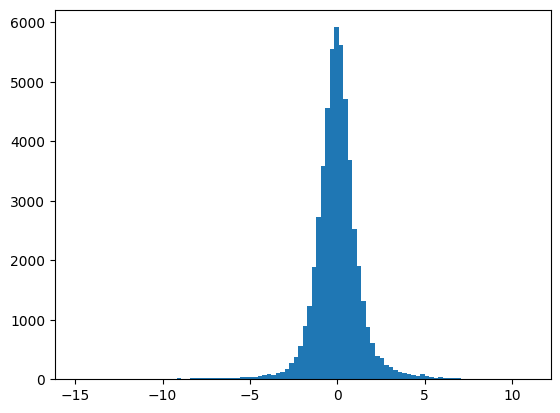

In [55]:
import matplotlib.pyplot as plt

plt.hist(queries[10].reshape(-1).float().numpy(), bins=100);

In [12]:
[indices[0].unique() for indices in cache.indices]

[tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0'),
 tensor([0], device='cuda:0')]

In [13]:
[indices[2].unique() for indices in cache.indices]

[tensor([   0,    1,    2,  ..., 8702, 8703, 8704], device='cuda:0'),
 tensor([   0,    1,    2,  ..., 8702, 8703, 8704], device='cuda:0'),
 tensor([   0,    1,    3,  ..., 8702, 8703, 8704], device='cuda:0'),
 tensor([   0,    1,    2,  ..., 8702, 8703, 8704], device='cuda:0'),
 tensor([   1,    2,    3,  ..., 8702, 8703, 8704], device='cuda:0'),
 tensor([   0,    1,    2,  ..., 8700, 8703, 8704], device='cuda:0'),
 tensor([   0,    1,    2,  ..., 8701, 8702, 8703], device='cuda:0'),
 tensor([   0,    1,    2,  ..., 8699, 8702, 8703], device='cuda:0'),
 tensor([   0,    1,    2,  ..., 8702, 8703, 8704], device='cuda:0'),
 tensor([   0,    1,    2,  ..., 8701, 8703, 8704], device='cuda:0'),
 tensor([   1,    2,    3,  ..., 8701, 8702, 8703], device='cuda:0'),
 tensor([   1,    2,    3,  ..., 8702, 8703, 8704], device='cuda:0'),
 tensor([   0,    1,    2,  ..., 8701, 8703, 8704], device='cuda:0'),
 tensor([   0,    1,    2,  ..., 8700, 8702, 8703], device='cuda:0'),
 tensor([   0,    1,

In [14]:
list(cache.indices[2][2].cpu().numpy())

[np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(4),
 np.int64(8),
 np.int64(28),
 np.int64(37),
 np.int64(53),
 np.int64(55),
 np.int64(56),
 np.int64(60),
 np.int64(65),
 np.int64(67),
 np.int64(72),
 np.int64(73),
 np.int64(75),
 np.int64(77),
 np.int64(83),
 np.int64(93),
 np.int64(97),
 np.int64(124),
 np.int64(126),
 np.int64(128),
 np.int64(129),
 np.int64(130),
 np.int64(140),
 np.int64(144),
 np.int64(146),
 np.int64(149),
 np.int64(155),
 np.int64(156),
 np.int64(157),
 np.int64(166),
 np.int64(170),
 np.int64(172),
 np.int64(176),
 np.int64(177),
 np.int64(178),
 np.int64(181),
 np.int64(187),
 np.int64(192),
 np.int64(198),
 np.int64(201),
 np.int64(205),
 np.int64(207),
 np.int64(220),
 np.int64(222),
 np.int64(226),
 np.int64(228),
 np.int64(230),
 np.int64(233),
 np.int64(234),
 np.int64(235),
 np.int64(242),
 np.int64(247),
 np.int64(249),
 np.int64(251),
 np.int64(252),
 np.int64(257),
 np.int64(262),
 np.int64(265),
 np.int64(275),
 np.int64(278),
 np.int64(283),
 